In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
# Create synthetic student ML exam dataset

np.random.seed(7)

n = 80

df = pd.DataFrame({
    'age': np.random.randint(19, 28, n),
    'study_hrs': np.random.uniform(1, 8, n).round(1),
    'assignments': np.random.randint(0, 10, n),
    'midterm': np.random.randint(30, 100, n),
    'final_score': None,
    'grade': None,
})

# Create final score
df['final_score'] = (
    df['study_hrs'] * 8
    + df['midterm'] * 0.5
    + np.random.randn(n) * 5
).clip(0, 100).round(1)

# Add missing values
df.loc[np.random.choice(n, 8), 'study_hrs'] = np.nan

# Create grade categories
df['grade'] = pd.cut(
    df['final_score'],
    bins=[0, 59, 74, 89, 100],
    labels=['F', 'C', 'B', 'A']
)

print("Dataset created successfully!")
print("Shape:", df.shape)

Dataset created successfully!
Shape: (80, 6)


In [8]:
# Display the first 5 rows
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 5 rows:


,age,study_hrs,assignments,midterm,final_score,grade
0,23,NaN,5,30,32.5,F
1,25,6.6,5,63,83.2,B
2,22,3.8,0,51,59.8,C
3,22,5.8,9,96,89.3,A
4,26,4.5,0,41,58.0,F



Column names:
['age', 'study_hrs', 'assignments', 'midterm', 'final_score', 'grade']

Data types:
age               int32
study_hrs       float64
assignments       int32
midterm           int32
final_score     float64
grade          category
dtype: object


In [9]:
# Check missing values before handling
print("Missing values before:")
print(df.isnull().sum())

# Fill missing study hours with the median
df['study_hrs'] = df['study_hrs'].fillna(df['study_hrs'].median())

# Check again
print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
age            0
study_hrs      8
assignments    0
midterm        0
final_score    0
grade          0
dtype: int64

Missing values after:
age            0
study_hrs      0
assignments    0
midterm        0
final_score    0
grade          0
dtype: int64


In [10]:
# Label Encoding for the target variable

label_encoder = LabelEncoder()

df['grade_encoded'] = label_encoder.fit_transform(df['grade'])

print("Grade categories:")
print(label_encoder.classes_)

print("\nEncoded grade values:")
print(df[['grade', 'grade_encoded']].head(10))

Grade categories:
['A' 'B' 'C' 'F']

Encoded grade values:
  grade  grade_encoded
0     F              3
1     B              1
2     C              2
3     A              0
4     F              3
5     C              2
6     F              3
7     A              0
8     C              2
9     B              1


In [11]:
# Create a categorical feature for OneHotEncoder demonstration

df['age_group'] = pd.cut(
    df['age'],
    bins=[18, 23, 28],
    labels=['Young', 'Adult']
)

# Apply OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)

age_group_encoded = one_hot_encoder.fit_transform(
    df[['age_group']]
)

# Convert encoded values into a DataFrame
one_hot_df = pd.DataFrame(
    age_group_encoded,
    columns=one_hot_encoder.get_feature_names_out(['age_group']),
    index=df.index
)

print("OneHotEncoder categories:")
print(one_hot_encoder.categories_)

print("\nOneHotEncoded values:")
display(one_hot_df.head())

OneHotEncoder categories:
[array(['Adult', 'Young'], dtype=object)]

OneHotEncoded values:


,age_group_Adult,age_group_Young
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0


In [12]:
# Create an ordered categorical feature

df['study_level'] = pd.cut(
    df['study_hrs'],
    bins=[0, 3, 5, 8],
    labels=['Low', 'Medium', 'High']
)

# Apply OrdinalEncoder
ordinal_encoder = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High']]
)

df['study_level_encoded'] = ordinal_encoder.fit_transform(
    df[['study_level']]
)

print("Ordinal categories:")
print(ordinal_encoder.categories_)

print("\nOrdinalEncoded values:")
display(df[['study_hrs', 'study_level', 'study_level_encoded']].head(10))

Ordinal categories:
[array(['Low', 'Medium', 'High'], dtype=object)]

OrdinalEncoded values:


,study_hrs,study_level,study_level_encoded
0,4.55,Medium,1.0
1,6.60,High,2.0
2,3.80,Medium,1.0
3,5.80,High,2.0
4,4.50,Medium,1.0
5,3.80,Medium,1.0
6,6.50,High,2.0
7,7.70,High,2.0
8,2.80,Low,0.0
9,4.60,Medium,1.0


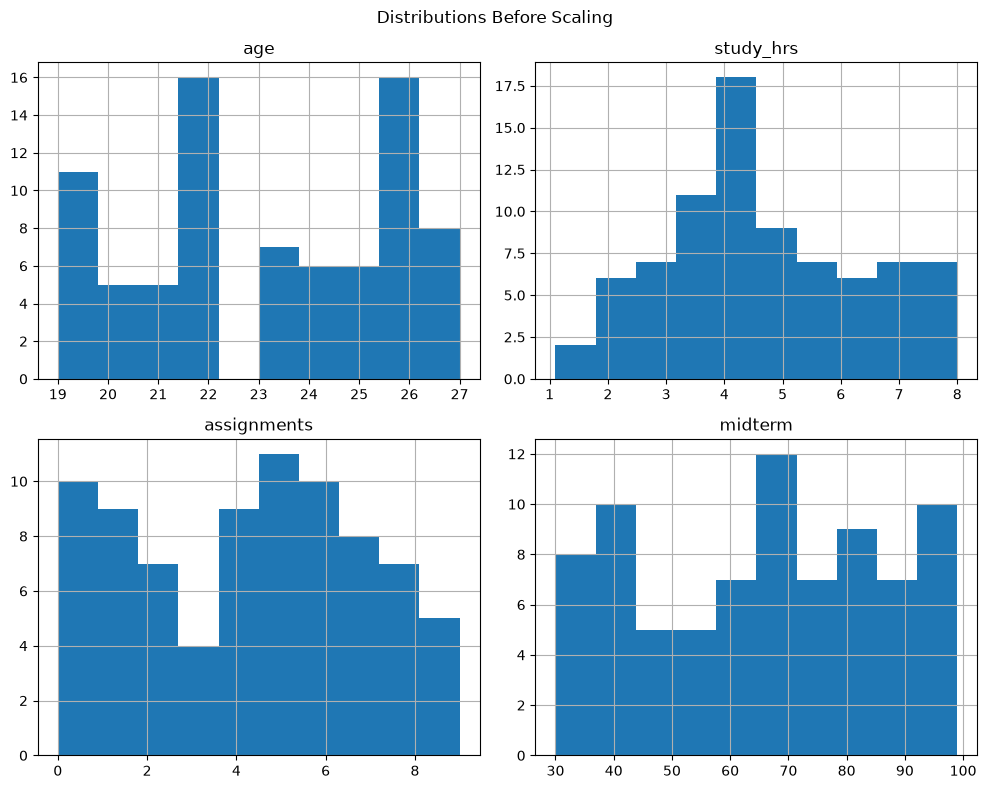

In [13]:
# Numerical features for scaling

numerical_features = [
    'age',
    'study_hrs',
    'assignments',
    'midterm'
]

# Plot distributions before scaling
df[numerical_features].hist(
    figsize=(10, 8),
    bins=10
)

plt.suptitle("Distributions Before Scaling")
plt.tight_layout()
plt.show()

In [14]:
# Apply StandardScaler

standard_scaler = StandardScaler()

df_standard = df[numerical_features].copy()

df_standard[numerical_features] = standard_scaler.fit_transform(
    df_standard[numerical_features]
)

print("StandardScaler applied successfully!")

print("\nFirst 5 rows after StandardScaler:")
display(df_standard.head())

print("\nMean after scaling:")
print(df_standard.mean().round(2))

StandardScaler applied successfully!

First 5 rows after StandardScaler:


,age,study_hrs,assignments,midterm
0,-0.061591,-0.100117,0.254629,-1.713107
1,0.696448,1.116115,0.254629,-0.128453
2,-0.440610,-0.545080,-1.532243,-0.704691
3,-0.440610,0.641488,1.684127,1.456201
4,1.075467,-0.129781,-1.532243,-1.184889



Mean after scaling:
age           -0.0
study_hrs     -0.0
assignments    0.0
midterm        0.0
dtype: float64


In [15]:
# Apply MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df[numerical_features].copy()

df_minmax[numerical_features] = minmax_scaler.fit_transform(
    df_minmax[numerical_features]
)

print("MinMaxScaler applied successfully!")

print("\nFirst 5 rows after MinMaxScaler:")
display(df_minmax.head())

print("\nMinimum values:")
print(df_minmax.min().round(2))

print("\nMaximum values:")
print(df_minmax.max().round(2))


MinMaxScaler applied successfully!

First 5 rows after MinMaxScaler:


,age,study_hrs,assignments,midterm
0,0.500,0.500000,0.555556,0.000000
1,0.750,0.797101,0.555556,0.478261
2,0.375,0.391304,0.000000,0.304348
3,0.375,0.681159,1.000000,0.956522
4,0.875,0.492754,0.000000,0.159420



Minimum values:
age            0.0
study_hrs      0.0
assignments    0.0
midterm        0.0
dtype: float64

Maximum values:
age            1.0
study_hrs      1.0
assignments    1.0
midterm        1.0
dtype: float64


In [16]:
# Apply RobustScaler

robust_scaler = RobustScaler()

df_robust = df[numerical_features].copy()

df_robust[numerical_features] = robust_scaler.fit_transform(
    df_robust[numerical_features]
)

print("RobustScaler applied successfully!")

print("\nFirst 5 rows after RobustScaler:")
display(df_robust.head())

RobustScaler applied successfully!

First 5 rows after RobustScaler:


,age,study_hrs,assignments,midterm
0,0.0,0.000000,0.000000,-1.104478
1,0.4,0.901099,0.000000,-0.119403
2,-0.2,-0.329670,-1.176471,-0.477612
3,-0.2,0.549451,0.941176,0.865672
4,0.6,-0.021978,-1.176471,-0.776119


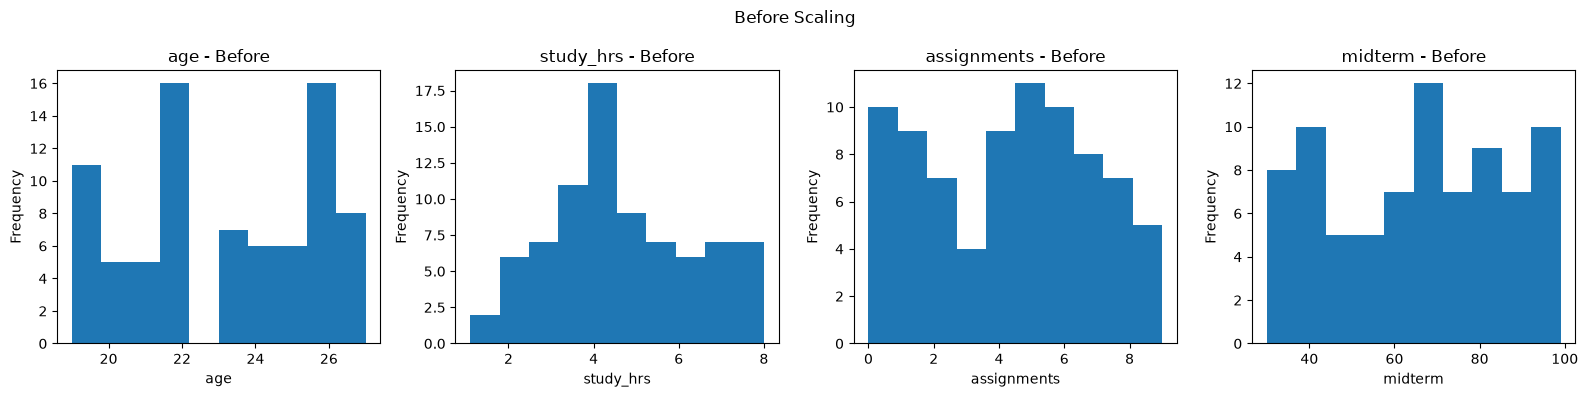

In [17]:
# Compare distributions before and after StandardScaler

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(numerical_features):
    axes[i].hist(df[feature], bins=10)
    axes[i].set_title(f'{feature} - Before')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Before Scaling')
plt.tight_layout()
plt.show()

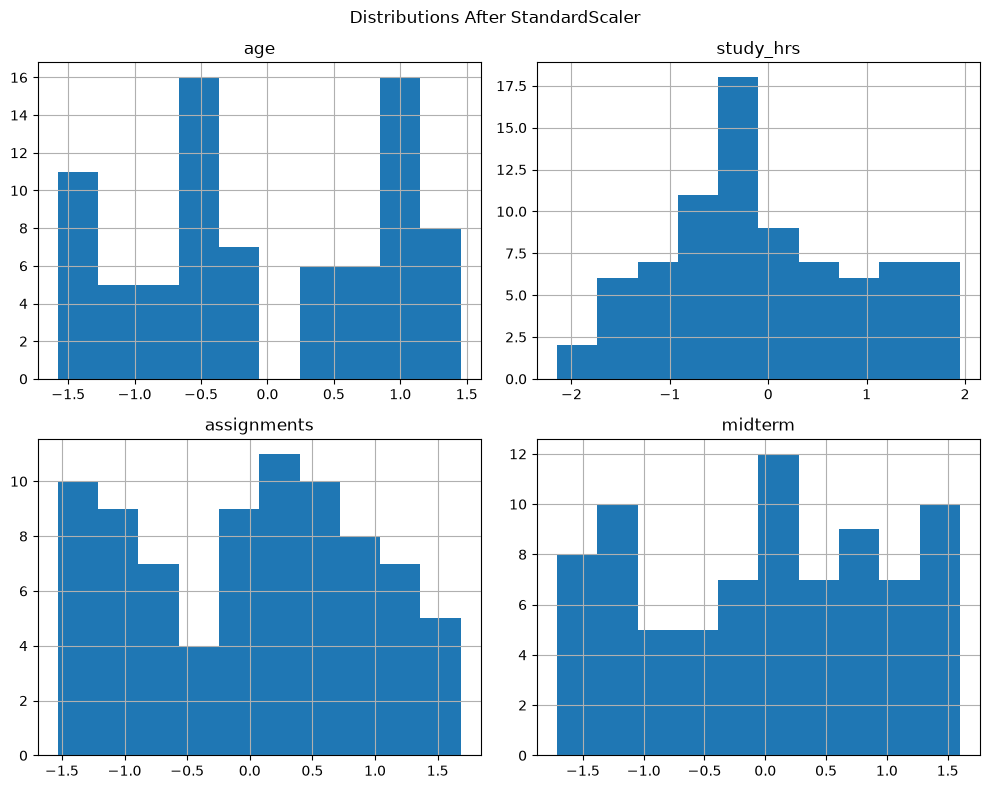

In [18]:
# Distributions after StandardScaler

df_standard[numerical_features].hist(
    figsize=(10, 8),
    bins=10
)

plt.suptitle("Distributions After StandardScaler")
plt.tight_layout()
plt.show()

In [19]:
# Prepare features for SelectKBest

X = pd.concat([
    df[numerical_features],
    one_hot_df,
    df[['study_level_encoded']]
], axis=1)

y = df['grade_encoded']

print("Feature columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])
print("Target:", y.name)

Feature columns:
['age', 'study_hrs', 'assignments', 'midterm', 'age_group_Adult', 'age_group_Young', 'study_level_encoded']

Number of features: 7
Target: grade_encoded


In [20]:
# Select the top 5 features

selector = SelectKBest(score_func=f_classif, k=5)

X_selected = selector.fit_transform(X, y)

# Get the selected feature names
selected_features = X.columns[selector.get_support()]

print("Top 5 selected features:")
print(selected_features.tolist())

print("\nFeature scores:")
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

display(feature_scores)

Top 5 selected features:
['age', 'study_hrs', 'midterm', 'age_group_Young', 'study_level_encoded']

Feature scores:


,Feature,Score
1,study_hrs,28.222057
6,study_level_encoded,20.605119
3,midterm,11.333964
0,age,2.182547
4,age_group_Adult,1.668334
5,age_group_Young,1.668334
2,assignments,0.091169


# Observations & Conclusion

## 1. Categorical Encoding

### LabelEncoder
LabelEncoder was used to convert the target variable `grade` into numerical values. 
The grade categories A, B, C, and F were converted into numerical labels so that 
machine learning algorithms can work with the target variable.

### OneHotEncoder
OneHotEncoder was used for the `age_group` categorical feature. Since the categories 
Young and Adult do not have an inherent numerical order, one-hot encoding represents 
each category separately without assigning an artificial ranking.

### OrdinalEncoder
OrdinalEncoder was used for the `study_level` feature. The categories Low, Medium, 
and High have a natural order, so they were encoded as 0, 1, and 2 respectively.

---

## 2. Feature Scaling

### StandardScaler
StandardScaler transforms numerical features so that they have approximately a mean 
of 0 and a standard deviation of 1. It is useful when features have different scales, 
but it can be affected by outliers.

### MinMaxScaler
MinMaxScaler transforms numerical values into a range between 0 and 1. It is useful 
when a bounded range is preferred, but it can also be sensitive to outliers.

### RobustScaler
RobustScaler uses the median and interquartile range (IQR) for scaling. Therefore, 
it is less affected by outliers compared with StandardScaler and MinMaxScaler.

---

## 3. Feature Selection using SelectKBest

SelectKBest with the ANOVA F-test (`f_classif`) was used to identify the five most 
relevant features for predicting the grade.

The selected top 5 features were:

1. age
2. study_hrs
3. midterm
4. age_group_Young
5. study_level_encoded

The highest feature score was obtained by `study_hrs`, followed by 
`study_level_encoded` and `midterm`.

The `assignments` feature had the lowest score and was not selected among the top 5.

---

## 4. Feature Leakage Prevention

Feature leakage occurs when information that would not normally be available at 
prediction time is used as an input feature.

In this dataset, `final_score` was not included as an input feature because the 
`grade` target was created directly from `final_score`. Including `final_score` 
could therefore provide information about the target and lead to data leakage.

Therefore, `final_score` was excluded from the feature matrix used for SelectKBest.

---

## 5. Conclusion

Feature engineering and encoding techniques were successfully applied to the 
synthetic student dataset. LabelEncoder, OneHotEncoder, and OrdinalEncoder were 
used for different types of categorical data. StandardScaler, MinMaxScaler, and 
RobustScaler were applied to numerical features and their distributions were 
compared before and after scaling. SelectKBest was then used to identify the top 
five features. These preprocessing and feature-selection techniques help prepare 
the dataset for machine learning and can improve model efficiency and 
interpretability.

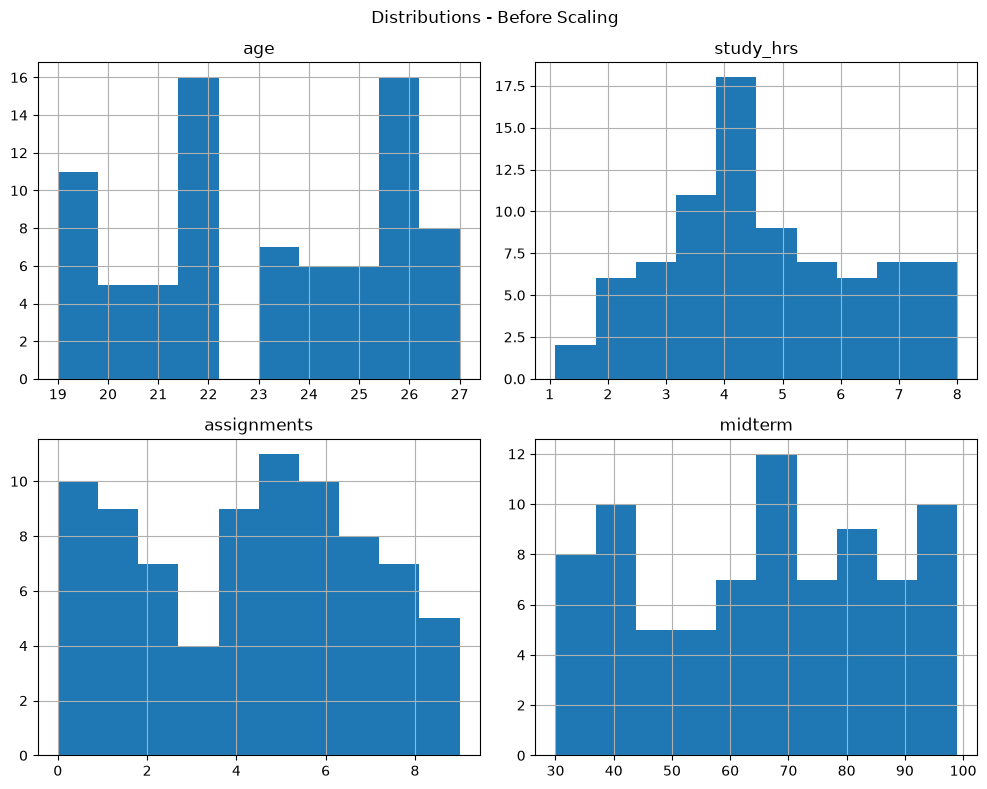

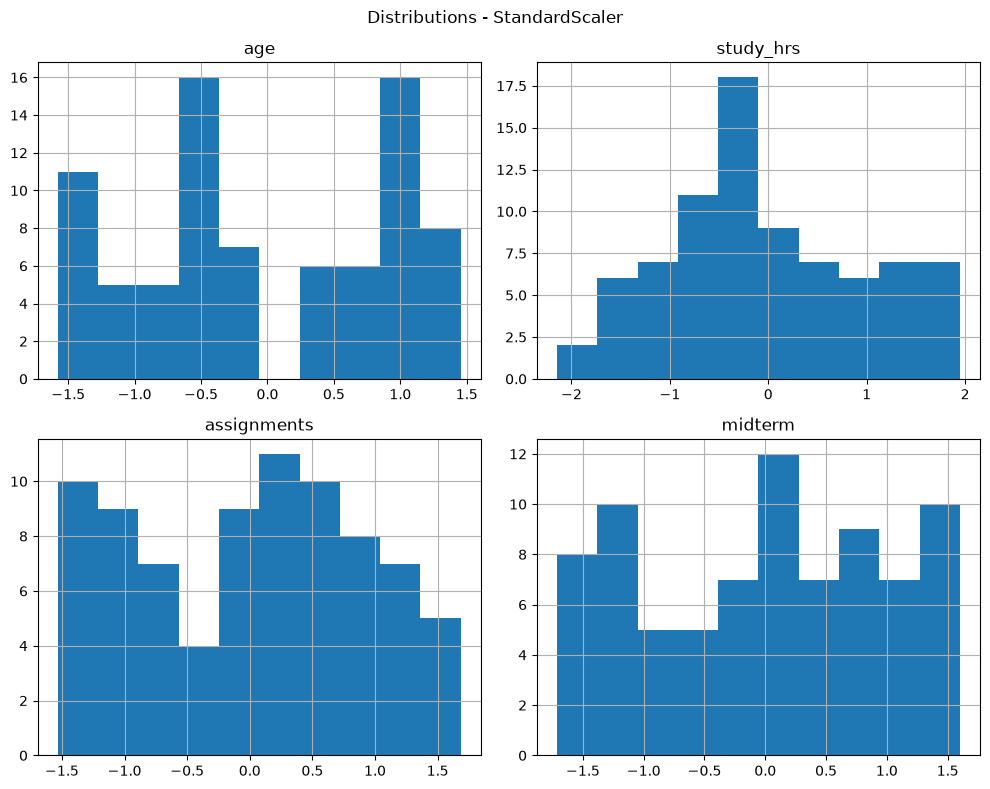

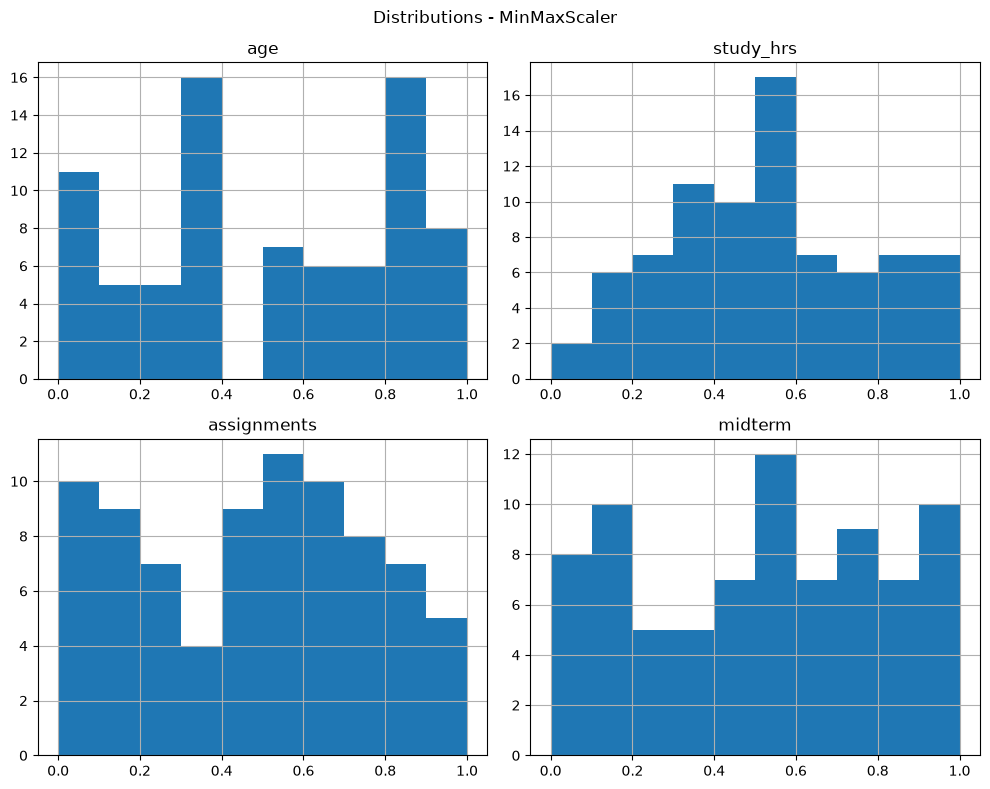

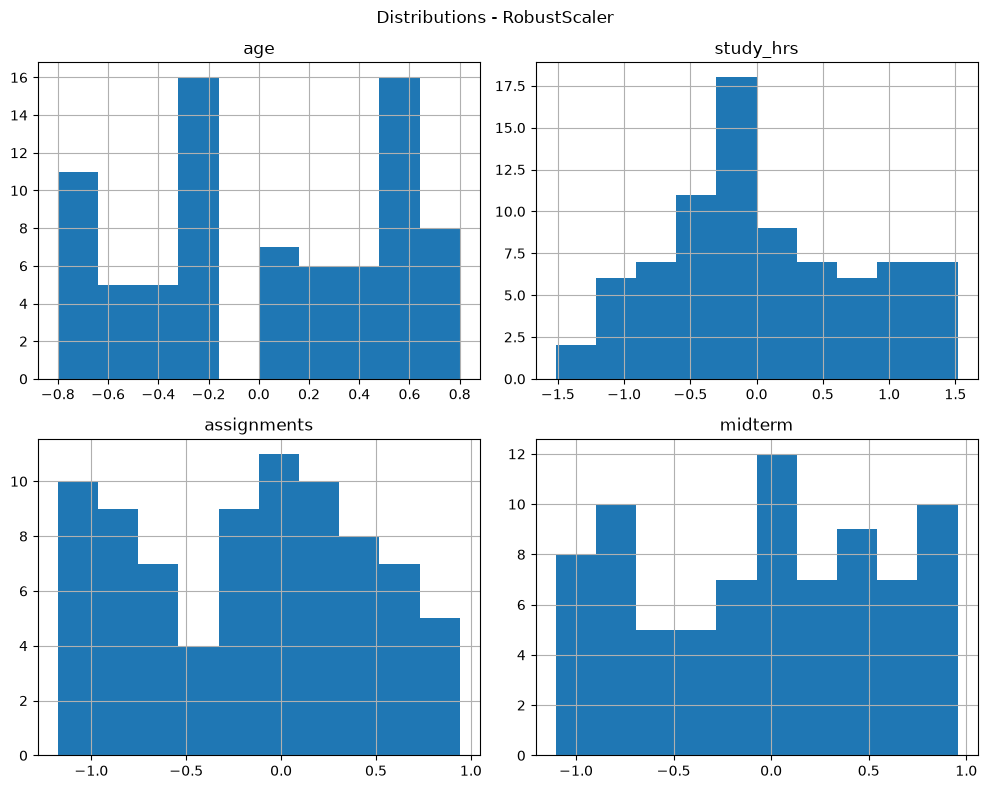

In [21]:
# Scaling Comparison: Before and After

scaled_data = {
    "Before Scaling": df[numerical_features],
    "StandardScaler": df_standard[numerical_features],
    "MinMaxScaler": df_minmax[numerical_features],
    "RobustScaler": df_robust[numerical_features]
}

for name, data in scaled_data.items():
    data.hist(figsize=(10, 8), bins=10)

    plt.suptitle(f"Distributions - {name}")
    plt.tight_layout()
    plt.show()